# What does Marketing get on Monday: each segment's list with its count, the members to ring first, the share of revenue the lists carry, and Q2 against plan?

**Week 2, Wednesday. The escalated case, alone, in five parts.** Parts 1 and 2 run in the
afternoon session; parts 3 to 5 run in the practice lab.

> "We start calling on Monday. Send me each segment's protect list under the head of
> Retail-Plus's rule, with its count; the members we ring first; how much of each segment's Q2
> revenue the lists cover; and one sentence Meera can take into the leadership meeting on
> whether Q2 is on track."
> The marketing lead, Kalpa Retail

**The situation.** Kalpa Retail sells to four segments: Business (corporate buyers, whose
orders run to lakhs), Retail-Core (everyday shoppers), Retail-Plus (the paid membership tier)
and Student. The head of Retail-Plus has asked that members who spent the same be ranked the
same and that every list say how many made the top fifty. The line is the last place a list
keeps, fiftieth on a top fifty. Marketing wants to ring the listed members whose monthly spend
fell two months running. Meera Raghavan, Kalpa Retail's CEO, wants to know whether Q2 is on
track against the plan line, by the total and week by week. This notebook builds all of it,
part by part, with nothing taken from elsewhere.

**Who needs the answer.** The marketing lead needs it because the team starts calling on
Monday, the head of Retail-Plus needs it to answer the tier's members for every call and every
count, and Meera needs one sentence to carry into the leadership meeting. A list with the wrong
count, a call to a member whose spend never fell, or a quarter misread against plan each costs
a decision.

**The questions on the way.**

- Which members make each segment's list under the head of Retail-Plus's rule, and how many in each?
- Which listed members does Marketing ring first?
- How much of each segment's Q2 revenue does its list carry?
- Is Q2 on track by the total and by the run rate?
- What goes to Marketing and Meera?

**The data.** Kalpa's Postgres warehouse holds `orders` (1,000 rows: order_id, customer_id,
order_date, quarter, channel, amount, status), `customers` (340 rows, one per member, with the
segment) and `plan_line` (one row per plan week: week_start, the Monday it starts, and
plan_revenue). Q2 is July to September 2026. Q2 revenue is booked revenue, every order at its
amount whatever its status, Rs 9,84,00,000 for the quarter. Monthly spend is a member's booked
revenue in one calendar month.

**This is the solution.** Every marker is filled with its key and the notebook runs clean from
the top. The reasons for each key, and the brief's five design items, are in
`exercises/solutions/C2_W02_D03_escalated_case_solution_STUDENT.md`. Where a part's answer
for Retail-Plus is the count your own run gave, this notebook checks it without printing it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = {}
print("connected:", kit.sql("select version()")[0]["version"].split(",")[0])

Q2_SPEND = """
    SELECT c.segment, o.customer_id, count(*) AS q2_orders, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id"""

MONTHLY = """
    SELECT customer_id, segment, date_trunc('month', order_date)::date AS month, sum(amount) AS spend
    FROM   orders JOIN customers USING (customer_id)
    GROUP  BY customer_id, segment, date_trunc('month', order_date)"""

connected: PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


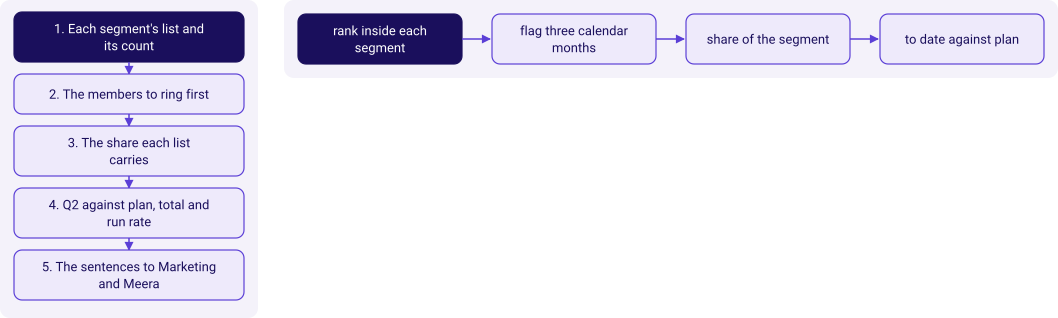

In [2]:
kit.side_by_side(
    kit.ladder(["Each segment's list and its count", "The members to ring first", "The share each list carries",
                "Q2 against plan, total and run rate", "The sentences to Marketing and Meera"], lit=0, show=False),
    kit.flow(["rank inside each segment", "flag three calendar months", "share of the segment", "to date against plan"],
             lit=0, show=False),
)

## Part 1. Which members make each segment's list under the head of Retail-Plus's rule, and how many in each?

Where this is used at work: the head of Retail-Plus asked for ties ranked the same and for
each list's count, so every list Kalpa ships states its rule and its count.

In [3]:
# TODO 1. Which function puts the head of Retail-Plus's rule into the window?
#   a) row_number(), which gives every member a place of their own, ties too
#   b) dense_rank(), which gives tied members one number and skips none
#   c) rank(), which gives tied members one number and skips the places used
#   d) count(*), which counts the members at or above each one's own figure
FUNCTION = {"a": "row_number()", "b": "dense_rank()", "c": "rank()", "d": "count(*)"}["c"]

# TODO 2. Which ORDER BY inside the window lets two members who spent the same tie?
#   a) ORDER BY q2_revenue DESC, customer_id
#   b) ORDER BY q2_revenue DESC
#   c) ORDER BY q2_revenue
#   d) ORDER BY customer_id
ORDER = {"a": "ORDER BY q2_revenue DESC, customer_id", "b": "ORDER BY q2_revenue DESC",
         "c": "ORDER BY q2_revenue", "d": "ORDER BY customer_id"}["b"]
PLACE = f"{FUNCTION} OVER (PARTITION BY segment {ORDER})"
list_sql = f"""WITH q2 AS ({Q2_SPEND}),
placed AS (SELECT segment, customer_id, q2_orders, q2_revenue, {PLACE} AS place FROM q2)
SELECT segment, customer_id, q2_orders, q2_revenue, place FROM placed WHERE place <= 50"""
protect = rows(list_sql)
counts = {}
for r in protect:
    counts[r["segment"]] = counts.get(r["segment"], 0) + 1
buyers = {r["segment"]: r["n"] for r in rows(f"SELECT segment, count(*) AS n FROM ({Q2_SPEND}) q2 GROUP BY 1")}
print("Lists built for:", ", ".join(sorted(counts)))

Lists built for: Business, Retail-Core, Retail-Plus, Student


In [4]:
kit.table(["segment", "members on the list", "members who bought"],
          [(s, counts.get(s, 0), buyers[s]) for s in sorted(buyers) if s != "Retail-Plus"],
          caption="The lists for Business, Retail-Core and Student; Retail-Plus's count is the one your run printed")

segment,members on the list,members who bought
Business,35,35
Retail-Core,50,96
Student,20,20


In [5]:
fiftieth = {r["segment"]: r["q2_revenue"] for r in rows(f"""SELECT segment, q2_revenue FROM (
    SELECT segment, q2_revenue, row_number() OVER (PARTITION BY segment ORDER BY q2_revenue DESC) AS n
    FROM ({Q2_SPEND}) q2) x WHERE n = 50""")}
at_or_above = {s: sum(1 for r in rows(f"SELECT segment, q2_revenue FROM ({Q2_SPEND}) q2")
                      if r["segment"] == s and r["q2_revenue"] >= fiftieth.get(s, 0)) for s in buyers}
print("Segments with a fiftieth member to measure the line against:", ", ".join(sorted(fiftieth)))

Segments with a fiftieth member to measure the line against: Retail-Core, Retail-Plus


In [6]:
last_kept = {}
for r in protect:
    last_kept[r["segment"]] = min(last_kept.get(r["segment"], 10 ** 12), r["q2_revenue"])
everyone = rows(f"SELECT segment, customer_id, q2_revenue FROM ({Q2_SPEND}) q2")
listed = {r["customer_id"] for r in protect}
kit.check("every segment has a list", set(counts) == set(buyers), ", ".join(sorted(counts)))
kit.check("each list holds fifty, or every buyer where a segment has fewer",
          all(counts.get(s, 0) >= min(50, buyers[s]) for s in buyers))
kit.check("nobody who spent at least the last listed member's figure is left off",
          all(r["customer_id"] in listed for r in everyone if r["segment"] in last_kept
              and r["q2_revenue"] >= last_kept[r["segment"]]))
kit.check("no list runs past the members at or above its fiftieth member's figure",
          all(counts.get(s, 0) <= at_or_above[s] for s in buyers))
kit.check("members who spent the same share a place",
          all(len({p["place"] for p in protect if p["segment"] == s and p["q2_revenue"] == v}) == 1
              for s, v in {(p["segment"], p["q2_revenue"]) for p in protect}))

## Part 2. Which listed members does Marketing ring first?

Where this is used at work: Marketing's member team rings a member whose own months show the
drift, and the data team writes the flag's definition down before the first call goes out.

In [7]:
# TODO 3. Which window keeps each member's months to themselves?
#   a) OVER (PARTITION BY segment ORDER BY month)
#   b) OVER (PARTITION BY customer_id ORDER BY month)
#   c) OVER (ORDER BY customer_id, month), since the sort keeps a member's months together
#   d) OVER (PARTITION BY month ORDER BY customer_id)
WINDOW = {"a": "OVER (PARTITION BY segment ORDER BY month)",
          "b": "OVER (PARTITION BY customer_id ORDER BY month)",
          "c": "OVER (ORDER BY customer_id, month)",
          "d": "OVER (PARTITION BY month ORDER BY customer_id)"}["b"]

# TODO 4. Which condition keeps a flag only for three calendar months in a row?
#   a) month_1_back = DATE '2026-08-01' AND month_2_back = DATE '2026-07-01'
#   b) spend_1_back IS NOT NULL AND spend_2_back IS NOT NULL
#   c) coalesce(spend_1_back, 0) > spend AND coalesce(spend_2_back, 0) > spend_1_back
#   d) month_1_back < month AND month_2_back < month_1_back
CALENDAR = {"a": "month_1_back = DATE '2026-08-01' AND month_2_back = DATE '2026-07-01'",
            "b": "spend_1_back IS NOT NULL AND spend_2_back IS NOT NULL",
            "c": "coalesce(spend_1_back, 0) > spend AND coalesce(spend_2_back, 0) > spend_1_back",
            "d": "month_1_back < month AND month_2_back < month_1_back"}["a"]

seg_of = {r["customer_id"]: r["segment"] for r in rows("SELECT customer_id, segment FROM customers")}
flag_sql = f"""WITH monthly AS ({MONTHLY}),
lagged AS (
    SELECT customer_id, month, spend,
           lag(spend, 1) {WINDOW} AS spend_1_back, lag(spend, 2) {WINDOW} AS spend_2_back,
           lag(month, 1) {WINDOW} AS month_1_back, lag(month, 2) {WINDOW} AS month_2_back,
           lag(customer_id, 1) {WINDOW} AS member_1_back, lag(customer_id, 2) {WINDOW} AS member_2_back
    FROM monthly)
SELECT customer_id, spend_2_back AS earlier, spend_1_back AS before, spend AS september,
       month_1_back, month_2_back, member_1_back, member_2_back
FROM lagged
WHERE month = DATE '2026-09-01' AND spend < spend_1_back AND spend_1_back < spend_2_back AND {CALENDAR}"""
flagged = rows(flag_sql)
to_ring = [r for r in flagged if r["customer_id"] in listed]
kit.stats([(len(flagged), "members flagged", "three calendar months, each lower"),
           (len(to_ring), "on a protect list", "Marketing's first calls")],
          caption="The members Marketing rings first")

In [8]:
crossed = rows(f"""SELECT count(*) AS n FROM (SELECT customer_id, lag(customer_id) {WINDOW} AS prev
                                         FROM ({MONTHLY}) m) x WHERE prev <> customer_id""")[0]["n"]
kit.check("your window never reads past the start of a member's own months", crossed == 0, f"{crossed} rows cross")
kit.check("the flag finds members to ring", len(to_ring) > 0)
kit.check("no flag compares a member with another member's month",
          all(r["member_1_back"] == r["customer_id"] == r["member_2_back"] for r in flagged))
bought_in = {}
for r in rows("""SELECT DISTINCT customer_id, extract(month FROM order_date)::int AS m FROM orders
                 WHERE order_date >= DATE '2026-07-01'"""):
    bought_in.setdefault(r["customer_id"], set()).add(r["m"])
kit.check("every flagged member placed an order in each of the three months the flag compares",
          all({7, 8, 9} <= bought_in.get(r["customer_id"], set()) for r in flagged))
kit.check("every flagged member's three months each fall", all(r["september"] < r["before"] < r["earlier"] for r in flagged))
kit.check("the member on holiday, C-0216, is not rung", "C-0216" not in {r["customer_id"] for r in to_ring})

## Part 3. How much of each segment's Q2 revenue does its list carry?

Where this is used at work: the marketing lead asked how much of each segment's Q2 revenue the
lists cover, so each list carries its share of the segment it was cut from.

In [9]:
# TODO 5. Which expression puts the segment's whole Q2 revenue beside every member's row?
#   a) sum(q2_revenue) OVER (PARTITION BY segment)
#   b) sum(q2_revenue) OVER (PARTITION BY segment ORDER BY q2_revenue DESC)
#   c) sum(q2_revenue) OVER ()
#   d) sum(q2_revenue) OVER (ORDER BY segment)
TOTAL = {"a": "sum(q2_revenue) OVER (PARTITION BY segment)",
         "b": "sum(q2_revenue) OVER (PARTITION BY segment ORDER BY q2_revenue DESC)",
         "c": "sum(q2_revenue) OVER ()",
         "d": "sum(q2_revenue) OVER (ORDER BY segment)"}["a"]

# TODO 6. Which share answers "how much of each segment's revenue does its list cover"?
#   a) the list's revenue over the book's Q2 revenue, Rs 9,84,00,000
#   b) the list's members over the segment's members who bought
#   c) the list's revenue over its own segment's whole Q2 revenue
#   d) the list's revenue over the four lists' revenue together
SHARE = "c"

share_sql = f"""WITH q2 AS ({Q2_SPEND})
SELECT segment, customer_id, q2_revenue,
       rank() OVER (PARTITION BY segment ORDER BY q2_revenue DESC) AS place,
       {TOTAL} AS segment_total
FROM q2"""
members = rows(share_sql)
book = sum(m["q2_revenue"] for m in members)
parts = []
for seg in sorted({m["segment"] for m in members}):
    mine = [m for m in members if m["segment"] == seg]
    kept = [m for m in mine if m["place"] <= 50]
    parts.append({"segment": seg, "list_revenue": sum(m["q2_revenue"] for m in kept), "listed": len(kept),
                  "bought": len(mine), "segment_total": mine[0]["segment_total"]})
all_lists = sum(r["list_revenue"] for r in parts)
def share_of(r):
    return {"a": r["list_revenue"] / book, "b": r["listed"] / r["bought"],
            "c": r["list_revenue"] / r["segment_total"], "d": r["list_revenue"] / all_lists}[SHARE]
shares = [(r["segment"], share_of(r)) for r in parts]
print("Shares computed for:", ", ".join(s for s, v in shares if v is not None))

Shares computed for: Business, Retail-Core, Retail-Plus, Student


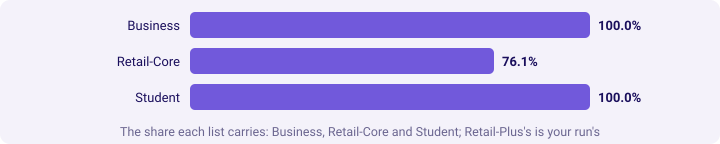

In [10]:
kit.bars([(s, round(100 * v, 1)) for s, v in shares if v is not None and s != "Retail-Plus"],
         title="The share each list carries: Business, Retail-Core and Student; Retail-Plus's is your run's",
         fmt=lambda v: f"{v:.1f}%")

In [11]:
seg_rev = {r["segment"]: r["q2_revenue"] for r in rows(f"SELECT segment, sum(q2_revenue) AS q2_revenue FROM ({Q2_SPEND}) q2 GROUP BY 1")}
kit.check("every row carries its segment's whole Q2 revenue", all(m["segment_total"] == seg_rev[m["segment"]] for m in members))
second = {r["segment"]: float(r["share"]) for r in rows(f"""WITH q2 AS ({Q2_SPEND}),
    placed AS (SELECT segment, q2_revenue, rank() OVER (PARTITION BY segment ORDER BY q2_revenue DESC) AS place FROM q2)
    SELECT segment, sum(q2_revenue) FILTER (WHERE place <= 50) / sum(q2_revenue) AS share FROM placed GROUP BY segment""")}
kit.check("each segment's share agrees with a second count made straight from the warehouse",
          all(v is not None and abs(v - second[s]) < 1e-9 for s, v in shares))

## Part 4. Is Q2 on track by the total and by the run rate?

Where this is used at work: Meera reads the quarter twice, by the total so far and by how each
week is running, and the two can disagree.

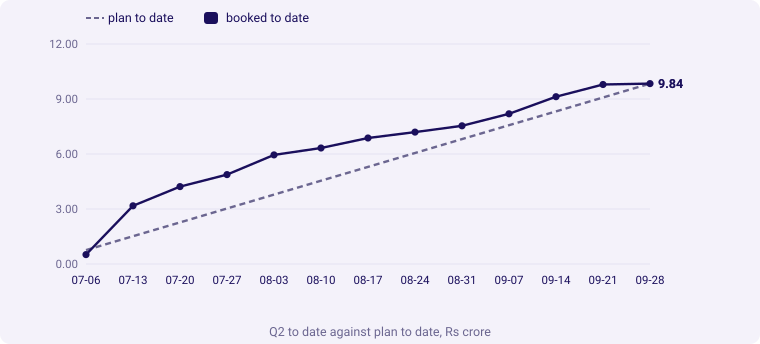

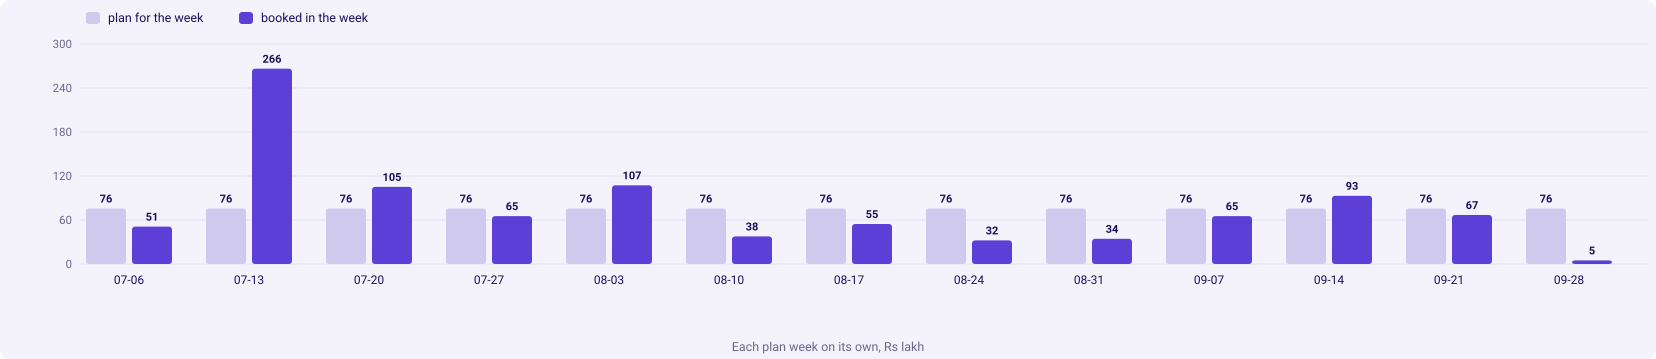

Close: Rs 9,84,00,000 against Rs 9,83,99,990; mid-quarter: Rs 1,57,51,980 ahead; full weeks from 10 August below plan: 6 of 7


In [12]:
# TODO 7. Which expression gives every Q2 order a plan week that the plan line holds?
#   a) date_trunc('week', order_date)::date, the Monday that starts each order's own calendar week
#   b) greatest(date_trunc('week', order_date)::date, (SELECT min(week_start) FROM plan_line))
#   c) date_trunc('month', order_date)::date, which files each order under the first day of its month
#   d) (order_date - 5), which moves every order back five days before it meets a plan week
WEEK = {"a": "date_trunc('week', order_date)::date",
        "b": "greatest(date_trunc('week', order_date)::date, (SELECT min(week_start) FROM plan_line))",
        "c": "date_trunc('month', order_date)::date",
        "d": "(order_date - 5)"}["b"]

plan_sql = f"""WITH weekly AS (
    SELECT {WEEK} AS week_start, sum(amount) AS booked FROM orders WHERE quarter = 'Q2' GROUP BY 1),
joined AS (SELECT p.week_start, p.plan_revenue, coalesce(w.booked, 0) AS booked
           FROM plan_line p LEFT JOIN weekly w USING (week_start))
SELECT week_start, plan_revenue, booked,
       sum(plan_revenue) OVER (ORDER BY week_start) AS plan_to_date,
       sum(booked) OVER (ORDER BY week_start) AS booked_to_date
FROM joined ORDER BY week_start"""
weeks = rows(plan_sql)
kit.line([str(w["week_start"])[5:] for w in weeks],
         [("plan to date", [w["plan_to_date"] / 1e7 for w in weeks], "plan"),
          ("booked to date", [w["booked_to_date"] / 1e7 for w in weeks], "lit")],
         title="Q2 to date against plan to date, Rs crore", fmt=lambda v: f"{v:.2f}")
kit.columns([str(w["week_start"])[5:] for w in weeks],
            [("plan for the week", [w["plan_revenue"] / 1e5 for w in weeks]),
             ("booked in the week", [w["booked"] / 1e5 for w in weeks])],
            title="Each plan week on its own, Rs lakh", fmt=lambda v: f"{v:,.0f}")

# TODO 8. Which comparison counts the weeks that ran below plan, each week on its own?
#   a) booked_to_date < plan_to_date
#   b) booked < plan_revenue
#   c) booked < plan_to_date
#   d) sum(booked) < sum(plan_revenue) over the seven weeks
RUN_RATE = "b"
since = [w for w in weeks if "2026-08-10" <= str(w["week_start"]) <= "2026-09-21"]
below = {"a": sum(w["booked_to_date"] < w["plan_to_date"] for w in since),
         "b": sum(w["booked"] < w["plan_revenue"] for w in since),
         "c": sum(w["booked"] < w["plan_to_date"] for w in since),
         "d": int(sum(w["booked"] for w in since) < sum(w["plan_revenue"] for w in since))}[RUN_RATE]
print(f"Close: {kit.rupees(weeks[-1]['booked_to_date'])} against {kit.rupees(weeks[-1]['plan_to_date'])}; "
      f"mid-quarter: {kit.rupees(weeks[6]['booked_to_date'] - weeks[6]['plan_to_date'])} ahead; "
      f"full weeks from 10 August below plan: {below} of {len(since)}")

In [13]:
q2_total = rows("SELECT sum(amount) AS t FROM orders WHERE quarter = 'Q2'")[0]["t"]
kit.check("the running total closes on Q2's own total", weeks[-1]["booked_to_date"] == q2_total)
kit.check("every plan week carries a to-date that never falls", all(b["booked_to_date"] >= a["booked_to_date"]
                                                                   for a, b in zip(weeks, weeks[1:])))
short_weeks = rows("""SELECT count(*) AS n FROM (
    SELECT p.week_start, p.plan_revenue, (SELECT coalesce(sum(o.amount), 0) FROM orders o
           WHERE o.order_date BETWEEN p.week_start AND p.week_start + 6) AS week_booked
    FROM plan_line p WHERE p.week_start BETWEEN DATE '2026-08-10' AND DATE '2026-09-21') x
    WHERE week_booked < plan_revenue""")[0]["n"]
kit.check("your count of weeks below plan agrees with a count made week by week from the orders",
          below == short_weeks and len(since) == 7)

## Part 5. What goes to Marketing and Meera?

Where this is used at work: Meera takes one sentence into the leadership meeting, so each
number in it has to hold on its own.

In [14]:
# TODO 9. Which sentence goes to Meera for the leadership meeting?
#   a) "Q2 closed Rs 15,39,810 short of plan on the running total, so the next quarter should open on a recovery campaign to win it back."
#   b) "Q2 closed on plan and stood Rs 1.58 crore ahead at mid-quarter, so the quarter needs no action from the leadership meeting at all."
#   c) "Q2 closed on plan, Rs 10 ahead; the mid-quarter lead came from one July week, and six of seven weeks since 10 August ran below."
#   d) "Q2 revenue to date stood at about nine times the weekly plan by mid-quarter, well ahead of every target the plan line set."
MEERA = "c"

# TODO 10. Which sentence goes to Marketing with the lists?
#   a) "Every segment's list holds exactly fifty members, cut by a tiebreaker stated in advance, so each list is the same size for the calls."
#   b) "Each list holds fifty, or every buyer where a segment has fewer, and a list above fifty names the members tied at its line."
#   c) "The lists hold 155 members in all, fifty per segment where possible, ranked by Q2 revenue across the whole book."
#   d) "Each list ranks members with DENSE_RANK, so members who spent the same share a place and no number is skipped."
MARKETING = "b"
print("To Meera:", MEERA, "| To Marketing:", MARKETING)

To Meera: c | To Marketing: b


In [15]:
# What each sentence claims, set against what this notebook computed.
close_gap = weeks[-1]["booked_to_date"] - weeks[-1]["plan_to_date"]
meera_says = {"a": (-1539810, None), "b": (10, None), "c": (10, 6), "d": (None, None)}
kit.check("the sentence to Meera carries the close and the weeks below plan this notebook computed",
          meera_says[MEERA] == (close_gap, below))
marketing_says = {
    "a": all(counts.get(s, 0) == 50 for s in buyers),
    "b": all(counts.get(s, 0) in (min(50, buyers[s]), at_or_above[s]) for s in buyers),
    "c": False,
    "d": FUNCTION == "dense_rank()",
}
kit.check("the sentence to Marketing describes the lists part 1 built", marketing_says[MARKETING])
kit.check_summary()